# DATA STRUCTURE 2 FIGURE 

In [1]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data


## The *Present*

In [19]:
#### Read in data 
present_df = pd.read_csv('present_ds2_right_eye_df.csv')
present_df = present_df.iloc[:, 1:]
print(present_df.head())
print(present_df.shape)

    rightEyeX   rightEyeY     times      subjectID
0  629.099976  518.599976 -1.367178  sub-A00008326
1  629.700012  519.400024 -1.365070  sub-A00008326
2  629.700012  519.400024 -1.363065  sub-A00008326
3  627.400024  524.000000 -1.361112  sub-A00008326
4  623.799988  529.200012 -1.359141  sub-A00008326
(12527062, 4)


In [13]:
### descriptive stats 
present_number_subjects = len(present_df['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df, 'rightEyeX')
print("*"*10)
yy = descr_stats(present_df, 'rightEyeY')

Number of subjects in PRESENT: 115
Summary stats for column: rightEyeX
mean    -1927.916931
min    -32768.000000
max      2559.699951
std      8921.628328
Name: rightEyeX, dtype: float64
**********
Summary stats for column: rightEyeY
mean    -2058.005685
min    -32768.000000
max      2046.800049
std      8882.972553
Name: rightEyeY, dtype: float64


In [ ]:
records = []

for subj, grp in present_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

Summary stats for column: sample_rate_hz
mean    499.873043
min     359.100000
max     520.900000
std      20.794269
Name: sample_rate_hz, dtype: float64
Summary stats for column: x_min
mean   -32198.121739
min    -32768.000000
max         0.000000
std      4302.320983
Name: x_min, dtype: float64
Summary stats for column: y_min
mean   -32198.121739
min    -32768.000000
max         0.000000
std      4302.320983
Name: y_min, dtype: float64
unique sampling rate in sample: [505.3, 502.9, 503.3, 517.2, 497.7, 506.6, 508.2, 504.6, 497.3, 503.5, 505.5, 504.9, 505.9, 501.4, 500.8, 497.1, 501.1, 507.0, 505.2, 509.3, 505.8, 508.5, 504.1, 485.6, 500.0, 499.0, 502.8, 504.4, 503.0, 501.2, 498.9, 511.2, 502.7, 503.7, 501.5, 503.6, 520.9, 420.1, 497.0, 502.2, 503.2, 501.8, 504.7, 501.9, 499.6, 359.1, 507.8, 503.9, 505.0, 506.3, 512.3, 361.7, 506.4, 506.9, 501.3, 503.8, 499.7, 501.6, 485.2, 494.4, 496.3, 504.2, 507.4, 500.9, 506.7, 507.7, 502.5, 495.0, 502.6, 490.0, 498.7, 484.7, 506.0, 500.1, 507.2, 

### The *Present* FILTERED 

In [15]:
### present
# x
present_mean_x = present_df['rightEyeX'].mean()
present_sd_x = present_df['rightEyeX'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df['rightEyeX'].min()} and max x: {present_df['rightEyeX'].max()}")
print(f"present number of samples: {len(present_df)}")

# filter out oultiers 
present_df_filtered = present_df[
    (present_df['rightEyeX'] <= present_upper_x) &
    (present_df['rightEyeX'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df_filtered['rightEyeX'].mean()}, x_min: {present_df_filtered['rightEyeX'].min()}, x_max: {present_df_filtered['rightEyeX'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df['rightEyeY'].mean()
present_sd_y = present_df['rightEyeY'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df['rightEyeY'].min()} and max y: {present_df['rightEyeY'].max()}")

# filter out outliers 
present_df_filtered = present_df_filtered[
    (present_df_filtered['rightEyeY'] <= present_upper_y) &
    (present_df_filtered['rightEyeY'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df_filtered['rightEyeY'].mean()}, y_min: {present_df_filtered['rightEyeY'].min()}, y_max: {present_df_filtered['rightEyeY'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")
print(f"Filter present number of subjects: {len(present_df['subjectID'].unique())}")

present x_corr mean: -1927.9169310710067 and std: 8921.628328148188
present x_corr upper: 20376.153889299465 and lower: -24231.987751441477
present x_corr min x: -32768.0 and max x: 2559.699951171875
present number of samples: 12527062
Filter present mean x: 651.4910385655261, x_min: -1279.5999755859375, x_max: 2559.699951171875
Filter present number of samples lost: 966873
**************************************************
present y_corr mean: -2058.0056852035495 and std: 8882.972552968735
present y_corr upper: 20149.42569721829 and lower: -24265.437067625386
present y_corr min y: -32768.0 and max y: 2046.800048828125
Filtered present mean y: 510.52189969408386, y_min: -1023.7000122070312, y_max: 2046.800048828125
Filter present number of samples lost: 966873
Filter present number of subjects: 115


### The *Present* RAW PLOT

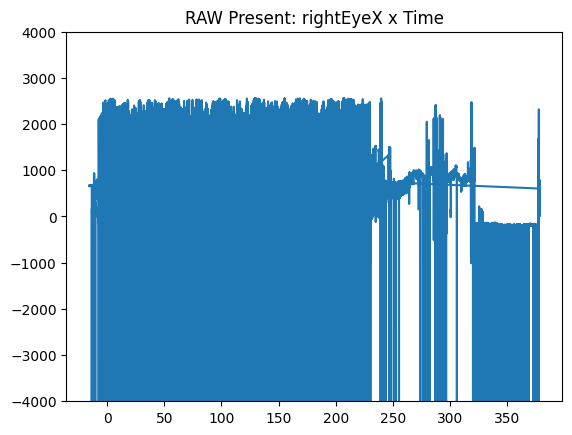

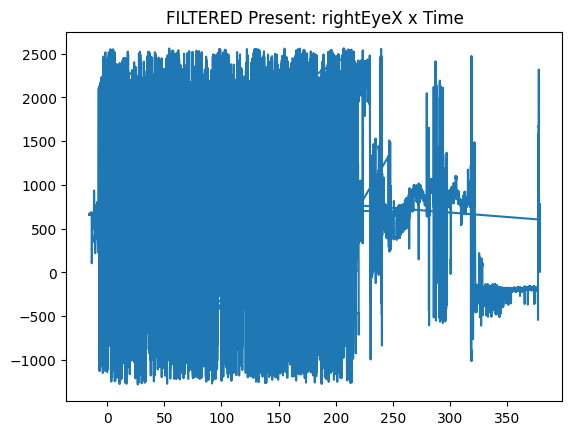

In [23]:
plt.plot(present_df['times'], present_df['rightEyeX'])
plt.ylim(-4000,4000)
plt.title("RAW Present: rightEyeX x Time")
plt.show()

plt.plot(present_df_filtered['times'], present_df_filtered['rightEyeX'])
# plt.ylim(-500,1500)
plt.title("FILTERED Present: rightEyeX x Time")
plt.show()

### The *Present* STANDARIZED 

In [16]:
# present 
present_df_standard = present_df_filtered
x_min_present = present_df_filtered['rightEyeX'].min()
x_max_present = present_df_filtered['rightEyeX'].max()
present_df_standard['x_norm'] = (present_df_standard['rightEyeX'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df_standard, 'x_norm')

print("*"*50)

y_min_present = present_df_filtered['rightEyeY'].min()
y_max_present = present_df_filtered['rightEyeY'].max()
present_df_standard['y_norm'] = (present_df_standard['rightEyeY'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.502980
min     0.000000
max     1.000000
std     0.058335
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.499665
min     0.000000
max     1.000000
std     0.056453
Name: y_norm, dtype: float64


### The *Present* PLOT

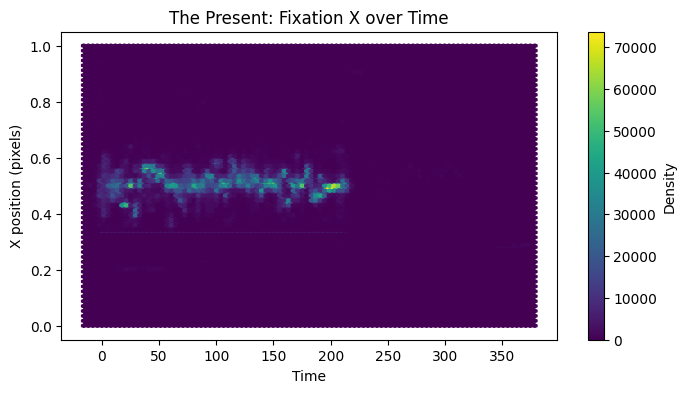

In [17]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_df_standard['times'],
    present_df_standard['x_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('The Present: Fixation X over Time')

plt.show()

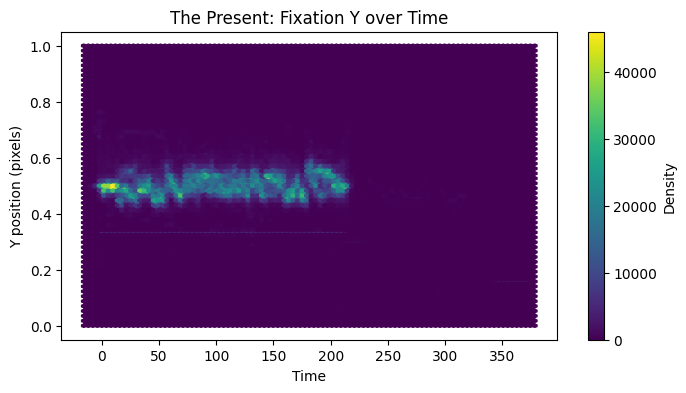

In [18]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_df_standard['times'],
    present_df_standard['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('The Present: Fixation Y over Time')

plt.show()

##  *Sherlock*

In [ ]:
### read in data 
sherlock_df = pd.read_csv("sherlock_ds2_right_eye_df.csv")
sherlock_df = sherlock_df.iloc[:, 1:]
print(sherlock_df.head())
print(sherlock_df.shape)

    rightEyeX   rightEyeY     times      subjectID
0  884.000000  529.299988 -1.433650  sub-A00008326
1  895.900024  519.099976 -1.433295  sub-A00008326
2  897.099976  507.399994 -1.431131  sub-A00008326
3  896.400024  507.600006 -1.429064  sub-A00008326
4  896.500000  506.799988 -1.427053  sub-A00008326
(35309166, 4)


In [20]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df, 'rightEyeX')
print("*"*10)
yy = descr_stats(sherlock_df, 'rightEyeY')

Number of subjects in SHERLOCK: 115
Summary stats for column: rightEyeX
mean    -3345.031095
min    -32768.000000
max      2560.000000
std     10809.838243
Name: rightEyeX, dtype: float64
**********
Summary stats for column: rightEyeY
mean    -3488.437897
min    -32768.000000
max      2047.800049
std     10755.604139
Name: rightEyeY, dtype: float64


In [6]:
records = []

for subj, grp in sherlock_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_62552/3326268928.py:31: RuntimeWarning: divide by zero encountered in divide
  velocity = dist / diffs                        # px/s
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_62552/3326268928.py:31: RuntimeWarning: invalid value encountered in divide
  velocity = dist / diffs                        # px/s
/opt/anaconda3/envs/nki_rockland_paper/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1845: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


Summary stats for column: sample_rate_hz
mean    501.730435
min     354.900000
max     956.500000
std      47.786376
Name: sample_rate_hz, dtype: float64
Summary stats for column: x_min
mean   -32198.121739
min    -32768.000000
max         0.000000
std      4302.320983
Name: x_min, dtype: float64
Summary stats for column: y_min
mean   -32198.121739
min    -32768.000000
max         0.000000
std      4302.320983
Name: y_min, dtype: float64
unique sampling rate in sample: [503.4, 496.2, 506.4, 503.2, 494.1, 506.2, 505.5, 504.0, 498.1, 508.3, 509.2, 502.6, 499.3, 492.1, 501.6, 493.6, 505.9, 500.1, 493.2, 491.7, 503.5, 504.1, 492.5, 505.2, 498.7, 506.6, 501.8, 499.6, 499.2, 502.7, 498.2, 497.0, 492.2, 501.1, 507.4, 503.1, 505.1, 406.6, 508.0, 501.0, 505.8, 505.7, 354.9, 504.4, 502.9, 499.4, 507.0, 358.9, 498.8, 502.4, 496.0, 492.0, 500.5, 497.7, 503.6, 505.0, 499.8, 956.5, 501.4, 500.8, 496.9, 485.9, 492.4, 509.0, 507.5, 497.4, 498.4, 503.9, 493.3, 508.8, 498.3, 490.3, 497.2, 503.0, 498.0, 

### *Sherlock* FILTERED 

In [7]:
### sherlock
# x
sherlock_mean_x = sherlock_df['rightEyeX'].mean()
sherlock_sd_x = sherlock_df['rightEyeX'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df['rightEyeX'].min()} and max x: {sherlock_df['rightEyeX'].max()}")
print(f"sherlock number of samples: {len(sherlock_df)}")

# filter out oultiers 
sherlock_df_filtered = sherlock_df[
    (sherlock_df['rightEyeX'] <= sherlock_upper_x) &
    (sherlock_df['rightEyeX'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df_filtered['rightEyeX'].mean()}, x_min: {sherlock_df_filtered['rightEyeX'].min()}, x_max: {sherlock_df_filtered['rightEyeX'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df['rightEyeY'].mean()
sherlock_sd_y = sherlock_df['rightEyeY'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df['rightEyeY'].min()} and max y: {sherlock_df['rightEyeY'].max()}")

# filter out outliers 
sherlock_df_filtered = sherlock_df_filtered[
    (sherlock_df_filtered['rightEyeY'] <= sherlock_upper_y) &
    (sherlock_df_filtered['rightEyeY'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df_filtered['rightEyeY'].mean()}, y_min: {sherlock_df_filtered['rightEyeY'].min()}, y_max: {sherlock_df_filtered['rightEyeY'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df['subjectID'].unique())}")

sherlock x_corr mean: -3345.0310948690626 and std: 10809.838242761169
sherlock x_corr upper: 23679.564512033856 and lower: -30369.626701771984
sherlock x_corr min x: -32768.0 and max x: 2560.0
sherlock number of samples: 35309166
Filter sherlock mean x: 623.9862897855583, x_min: -1279.300048828125, x_max: 2560.0
Filter sherlock number of samples lost: 4196896
**************************************************
sherlock y_corr mean: -3488.437896503501 and std: 10755.604139147972
sherlock y_corr upper: 23400.57245136643 and lower: -30377.44824437343
sherlock y_corr min y: -32768.0 and max y: 2047.800048828125
Filtered sherlock mean y: 461.23459842907783, y_min: -1023.5999755859376, y_max: 2047.800048828125
Filter sherlock number of samples lost: 4196896
Filter sherlock number of subjects: 115


### *Sherlock* STANDARIZED

In [8]:
# sherlock 
sherlock_df_standard = sherlock_df_filtered
x_min_sherlock = sherlock_df_filtered['rightEyeX'].min()
x_max_sherlock = sherlock_df_filtered['rightEyeX'].max()
sherlock_df_standard['x_norm'] = (sherlock_df_standard['rightEyeX'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df_filtered['rightEyeY'].min()
y_max_sherlock = sherlock_df_filtered['rightEyeY'].max()
sherlock_df_standard['y_norm'] = (sherlock_df_standard['rightEyeY'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.495738
min     0.000000
max     1.000000
std     0.074622
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.483439
min     0.000000
max     1.000000
std     0.067912
Name: y_norm, dtype: float64


### *Sherlock* PLOT

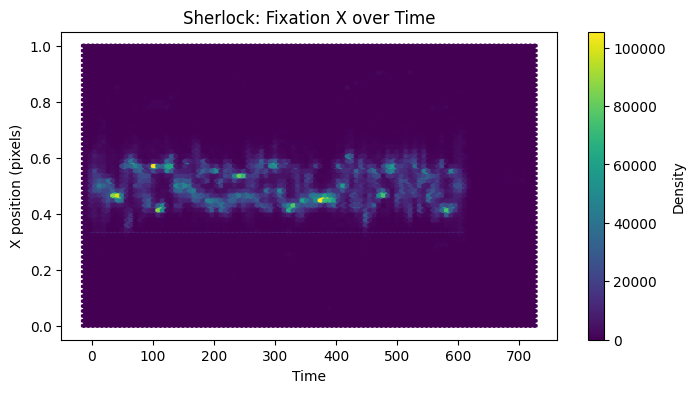

In [9]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_df_standard['times'],
    sherlock_df_standard['x_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('Sherlock: Fixation X over Time')

plt.show()

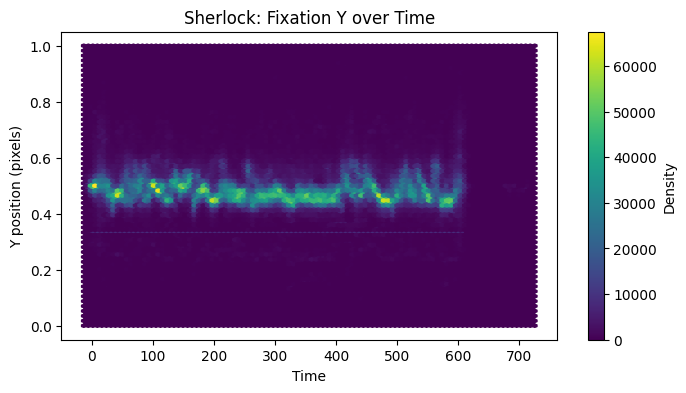

In [10]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_df_standard['times'],
    sherlock_df_standard['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('Sherlock: Fixation Y over Time')

plt.show()